<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/Part3_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3: DQN on Warehouse Navigation

We train a Deep Q-Network agent to navigate a 5x5 warehouse grid and reach a pallet, using the visual embeddings learned in Part 2 as part of the state representation.

The investigation has two threads.  First we compare three DQN variants in an additive fashion:
1. A vanilla version,
2. Experience replay,
3. Before + Target network on top.

Afterwards we run an ablation on the reward function we designed, since reward shaping is where the real design comes to play.

We start from a baseline Reward function provitional and then we wil improve it along our investigation, as well as improving the complexity of the gridd

In [1]:
import sys, os, json, random, time
from pathlib import Path
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL')
EMB_PATH = DRIVE_ROOT / 'embeddings' / 'mean_embeddings.npy'
ENV_PATH = DRIVE_ROOT / 'WarehouseEnv.py'
RESULTS_ROOT = DRIVE_ROOT / 'results_part3'
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

assert EMB_PATH.exists(), f"missing: {EMB_PATH}"
assert ENV_PATH.exists(), f"missing: {ENV_PATH}"
print("paths ok")

Mounted at /content/drive
paths ok


In [3]:
# add Drive folder to path so the warehouse file can be imported
sys.path.insert(0, str(DRIVE_ROOT))

# clear any cached version because in case of overwriting
if 'WarehouseEnv' in sys.modules:
    del sys.modules['WarehouseEnv']

import gymnasium
from WarehouseEnv import WarehouseEnv
print("env imported ok")

env imported ok


## Loading the Part 2 embeddings

The mean embeddings come from Part 2's best ResNet50 model (Variant C of Experiment 1, 99.05% test accuracy). They are stored as a dict keyed by class name, each pointing to a 2048-dim vector.

The environment looks them up by integer ID (0=floor, 1=wall, 2=pallet, 3=sign), so we remap the keys before passing the dict in.

In [4]:
emb_str = np.load(EMB_PATH, allow_pickle=True).item()
print("classes:", list(emb_str.keys()))
print("vector dim:", emb_str['floor'].shape)

# remap str keys to int IDs the env expects
NAME_TO_ID = {'floor': 0, 'wall': 1, 'pallet': 2, 'sign': 3}
emb = {NAME_TO_ID[k]: v.astype(np.float32) for k, v in emb_str.items()}
print("remapped keys:", list(emb.keys()))

classes: ['floor', 'wall', 'pallet', 'sign']
vector dim: (2048,)
remapped keys: [0, 1, 2, 3]


## Grid layout

We start with a minimal but non trivial 5x5 grid: the agent spawns at (0,0), the pallet sits at (4,4), and a single wall at the center forces the agent to learn a detour rather than going straight diagonal. No signs in this first version. (will change with commits)

When the experiments turn out too easy or the embeddings end up not contributing meaningfully, we'll come back here to make it harder.

Coordinate convention: `grid_map[row, col]` for the matrix, but the agent's position is stored as `(x, y)` where x is column and y is row, matching the env's movement code (LLMs detection).

In [5]:
# 0=floor, 1=wall, 2=pallet, 3=sign #for future experiment ?
GRID = [
    [0, 0, 1, 0, 0],
    [1, 0, 1, 0, 1],
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 1, 2],
]

# quick visual check
sym = {0:'.', 1:'#', 2:'P', 3:'S'}
for row in GRID:
    print(' '.join(sym[c] for c in row))

. . # . .
# . # . #
. . . . .
. # # # .
. . . # P


In [6]:
#SMOKE TEST
env = WarehouseEnv(grid_map=GRID, embeddings_dict=emb)

print("action space:", env.action_space)
print("obs space shape:", env.observation_space.shape)
print("target coords:", env.target_coords)

obs, info = env.reset()
print("initial obs shape:", obs.shape)
print("first 5 dims (xy + emb start):", obs[:5])

# also test one step to confirm the reward function works
obs, reward, term, trunc, info = env.step(3)  # action 3 = right
print(f"after step right: pos={env.agent_pos}, reward={reward}, term={term}")

action space: Discrete(4)
obs space shape: (2050,)
target coords: [4 4]
initial obs shape: (2050,)
first 5 dims (xy + emb start): [0.         0.         1.1220449  0.06864746 0.02758316]
after step right: pos=[1 0], reward=-0.05, term=False


## Random baseline

Before training anything, we measure how a random agent performs. This is just a sanity check that the env runs end-to-end across many episodes, and also a reference for future variations (the real ones).

We define three per episode metrics that we'll reuse in along the notebook: success (1 if the pallet was reached, 0 otherwise), episode length in steps, and total accumulated reward. Episodes are short to make them fast

New "harder" grid takes 8 steps to solve, and we are giving 100 MAx steps, to reduce accuracy but have also a "baseline of results"

In [7]:
MAX_STEPS = 100  # cap per episode, to solve it takes 8

def run_random(env, n_episodes=100, seed=0):
    rng = np.random.default_rng(seed)
    successes, lengths, rewards = [], [], []

    for ep in range(n_episodes):
        env.reset()
        ep_reward = 0.0
        for t in range(MAX_STEPS):
            action = rng.integers(0, env.action_space.n)
            _, r, term, trunc, _ = env.step(int(action))
            ep_reward += r
            if term or trunc:
                break
        successes.append(int(term))
        lengths.append(t + 1)
        rewards.append(ep_reward)

    return np.array(successes), np.array(lengths), np.array(rewards)

# run it
succ, lens, rews = run_random(env, n_episodes=100, seed=0)

print(f"Success rate:   {succ.mean():.2%}")
print(f"Avg ep length:  {lens.mean():.1f} steps")
print(f"Avg ep reward:  {rews.mean():.2f}")
print(f"Episodes that reached the pallet: {succ.sum()}/100")

Success rate:   30.00%
Avg ep length:  89.8 steps
Avg ep reward:  -26.40
Episodes that reached the pallet: 30/100


## Reading the baseline

We modify our grid to enforce a "harder" one, where we will expect a better improvement as we go along with the experiments

## V1: Vanilla DQN

At every step, we take an action, observe the result, and immediately do one gradient step on that single transition.

We run V1 with three different random seeds to get a sense of how much variance there is between runs.

In [8]:
class QNetwork(nn.Module):
    """
    Maps a state vector to Q-values for each action.
    Output convention (matches WarehouseEnv action_space):
      index 0 -> Up
      index 1 -> Down
      index 2 -> Left
      index 3 -> Right

    Two hidden layers with ReLU. Small network because the input is small
    (2 coords + 2048 embedding) and the action space is tiny (4).
    """
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


# quick sanity check that the net builds and produces the right shape
state_dim = env.observation_space.shape[0]   # 2050
action_dim = env.action_space.n              # 4
net = QNetwork(state_dim, action_dim).to(device)

# pass a dummy obs through it and check output shape
dummy = torch.zeros(1, state_dim).to(device)
out = net(dummy)
print(f"Net output shape: {out.shape}  (expected [1, 4])")
print(f"Trainable params: {sum(p.numel() for p in net.parameters()):,}")

Net output shape: torch.Size([1, 4])  (expected [1, 4])
Trainable params: 279,556


In [9]:
# hyperparameters: kept close to the FrozenLake DQN lab as a starting point
# we'll revisit if training is unstable or too slow
EPISODES = 500            # how many episodes per training run
LR = 1e-3                 # learning rate for the optimizer
GAMMA = 0.99              # discount factor on future rewards
EPS_START = 1.0           # start fully exploring
EPS_END = 0.05            # but never go below 5% exploration
EPS_DECAY = 0.995         # multiply epsilon by this each episode

def train_v1(env, seed=0, episodes=EPISODES, verbose=True):
    """
    Vanilla DQN one gradient step per env step on the latest transition.
    No replay buffer, no target net. Returns per episode metrics.
    """
    # seeding everything for reproducibility within a run
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # build a fresh net and optimizer for this run
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    net = QNetwork(state_dim, action_dim).to(device)
    opt = optim.Adam(net.parameters(), lr=LR)

    eps = EPS_START
    successes, lengths, total_rewards = [], [], []

    for ep in range(episodes):
        obs, _ = env.reset()
        ep_reward = 0.0

        for t in range(MAX_STEPS):
            # epsilon greedy action selection
            if random.random() < eps:
                action = random.randint(0, action_dim - 1)
            else:
                # pick argmax of Q-values from the net
                with torch.no_grad():
                    s = torch.from_numpy(obs).float().unsqueeze(0).to(device)
                    action = int(net(s).argmax(dim=1).item())

            # take the action
            next_obs, reward, term, trunc, _ = env.step(action)
            ep_reward += reward
            done = term or trunc

            # vanilla update one gradient step on this single transition
            # this is the part that V2 will replace with batch sampling from a buffer
            s = torch.from_numpy(obs).float().unsqueeze(0).to(device)
            ns = torch.from_numpy(next_obs).float().unsqueeze(0).to(device)
            a = torch.tensor([[action]], device=device)
            r = torch.tensor([[reward]], dtype=torch.float32, device=device)
            d = torch.tensor([[float(done)]], device=device)

            # Q(s, a) predicted by the net
            q_pred = net(s).gather(1, a)

            # target: r + gamma * max_a' Q(s', a'), zeroed if episode ended
            # using the same net for the target is what makes it "vanilla" (and unstable)
            with torch.no_grad():
                q_next = net(ns).max(dim=1, keepdim=True)[0]
                q_target = r + GAMMA * q_next * (1 - d)

            # MSE loss + step
            loss = F.mse_loss(q_pred, q_target)
            opt.zero_grad()
            loss.backward()
            opt.step()

            obs = next_obs
            if done:
                break

        # log episode outcome
        successes.append(int(term))
        lengths.append(t + 1)
        total_rewards.append(ep_reward)

        # decay epsilon (but not below the minimum)
        eps = max(EPS_END, eps * EPS_DECAY)

        # progress every 100 episodes
        if verbose and (ep + 1) % 100 == 0:
            recent = np.mean(successes[-100:])
            print(f"  ep {ep+1:4d} | last-100 success: {recent:.2%} | eps: {eps:.3f}")

    return {
        'successes': np.array(successes),
        'lengths': np.array(lengths),
        'rewards': np.array(total_rewards),
        'net': net,
    }

In [10]:
# run V1 three times with different seeds
# this gives us a sense of variance, how much does training depend on luck?
print("Training V1 vanilla DQN x3 seeds...")
v1_runs = []
for seed in [0, 1, 2]:
    print(f"\nSeed {seed}:")
    t0 = time.time()
    result = train_v1(env, seed=seed)
    print(f"  done in {time.time() - t0:.1f}s")
    v1_runs.append(result)

# quick summary
print("\nFinal 100-episode success rates per seed:")
for i, r in enumerate(v1_runs):
    final_succ = r['successes'][-100:].mean()
    print(f"  Seed {i}: {final_succ:.2%}")

Training V1 vanilla DQN x3 seeds...

Seed 0:
  ep  100 | last-100 success: 18.00% | eps: 0.606
  ep  200 | last-100 success: 6.00% | eps: 0.367
  ep  300 | last-100 success: 5.00% | eps: 0.222
  ep  400 | last-100 success: 0.00% | eps: 0.135
  ep  500 | last-100 success: 0.00% | eps: 0.082
  done in 116.6s

Seed 1:
  ep  100 | last-100 success: 13.00% | eps: 0.606
  ep  200 | last-100 success: 12.00% | eps: 0.367
  ep  300 | last-100 success: 0.00% | eps: 0.222
  ep  400 | last-100 success: 0.00% | eps: 0.135
  ep  500 | last-100 success: 0.00% | eps: 0.082
  done in 114.0s

Seed 2:
  ep  100 | last-100 success: 13.00% | eps: 0.606
  ep  200 | last-100 success: 9.00% | eps: 0.367
  ep  300 | last-100 success: 2.00% | eps: 0.222
  ep  400 | last-100 success: 0.00% | eps: 0.135
  ep  500 | last-100 success: 0.00% | eps: 0.082
  done in 113.6s

Final 100-episode success rates per seed:
  Seed 0: 0.00%
  Seed 1: 0.00%
  Seed 2: 0.00%


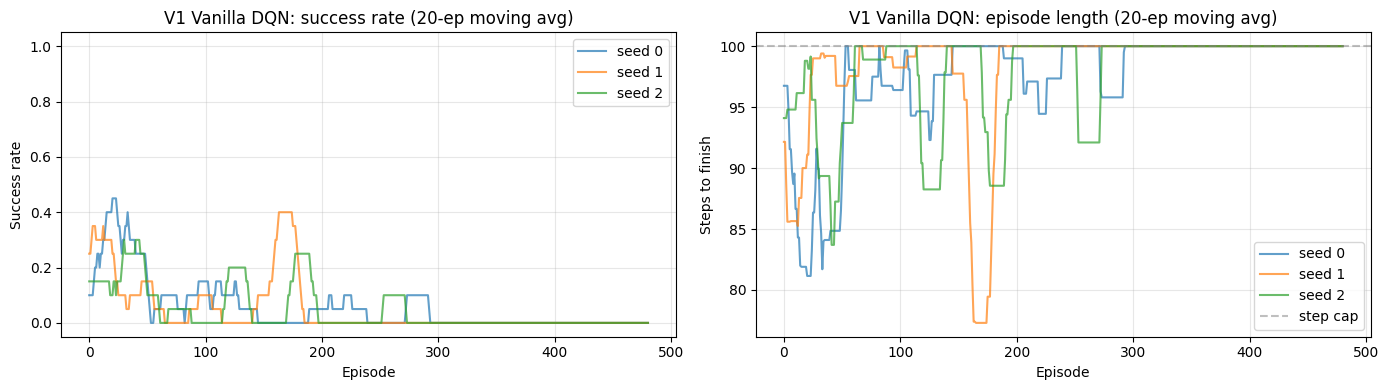

In [11]:
def smooth(arr, window=20):
    """Moving average for plotting noisy per-episode data."""
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: success rate over time (smoothed) for each seed
for i, r in enumerate(v1_runs):
    s = smooth(r['successes'], window=20)
    axes[0].plot(s, alpha=0.7, label=f'seed {i}')
axes[0].set_title('V1 Vanilla DQN: success rate (20-ep moving avg)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Success rate')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

# right: episode length over time
for i, r in enumerate(v1_runs):
    s = smooth(r['lengths'], window=20)
    axes[1].plot(s, alpha=0.7, label=f'seed {i}')
axes[1].set_title('V1 Vanilla DQN: episode length (20-ep moving avg)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps to finish')
axes[1].axhline(MAX_STEPS, color='gray', linestyle='--', alpha=0.5, label='step cap')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## V1 diagnosis

The three seeds tell the same story: partial learning during the early epsilon-high phase (13-18% success around episode 100), followed by a steady collapse to 0% by episode 300. Episode length saturates at the 100-step cap.

Identical failure across seeds means this is structural, not bad luck. Vanilla DQN trains on highly correlated consecutive transitions and chases a target produced by the same network it is updating, so once the policy drifts into a region where it can't find the pallet, it has no way to recover.

V2 addresses the correlation problem with an experience replay buffer.

## V2: DQN with Experience Replay

We add replay buffer. Each transition is stored, and at each step we sample a random batch from the buffer and train on that. The target is still computed by the same network, so the moving target problem from V1 remains.

In [12]:
class ReplayBuffer:
    """
    Fixed-size buffer that stores transitions and samples random batches.
    Uses deque so old transitions are dropped automatically when full.
    """
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, ns, done):
        self.buf.append((s, a, r, ns, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        # unzip into separate lists
        s, a, r, ns, d = zip(*batch)
        return s, a, r, ns, d

    def __len__(self):
        return len(self.buf)


# quick check that it works
buf = ReplayBuffer(100)
buf.push(np.zeros(2050), 0, 1.0, np.zeros(2050), False)
print(f"Buffer size after 1 push: {len(buf)}")

Buffer size after 1 push: 1


In [13]:
# new hyperparameters specific to V2
BUFFER_SIZE = 10000       # max transitions kept in memory
BATCH_SIZE = 64           # transitions sampled per gradient step
MIN_BUFFER = 256          # don't train until buffer has at least this many

def train_v2(env, seed=0, episodes=EPISODES, verbose=True):
    """
    DQN with experience replay. Same as V1 but trains on batches sampled
    from a buffer instead of the last transition.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    net = QNetwork(state_dim, action_dim).to(device)
    opt = optim.Adam(net.parameters(), lr=LR)
    buffer = ReplayBuffer(BUFFER_SIZE)

    eps = EPS_START
    successes, lengths, total_rewards = [], [], []

    for ep in range(episodes):
        obs, _ = env.reset()
        ep_reward = 0.0

        for t in range(MAX_STEPS):
            # epsilon-greedy as before
            if random.random() < eps:
                action = random.randint(0, action_dim - 1)
            else:
                with torch.no_grad():
                    s = torch.from_numpy(obs).float().unsqueeze(0).to(device)
                    action = int(net(s).argmax(dim=1).item())

            next_obs, reward, term, trunc, _ = env.step(action)
            ep_reward += reward
            done = term or trunc

            # store the transition instead of training on it directly
            buffer.push(obs, action, reward, next_obs, done)
            obs = next_obs

            # only train once we have enough transitions to sample a batch
            if len(buffer) >= MIN_BUFFER:
                # sample random batch and convert to tensors
                bs, ba, br, bns, bd = buffer.sample(BATCH_SIZE)
                bs = torch.from_numpy(np.array(bs)).float().to(device)
                bns = torch.from_numpy(np.array(bns)).float().to(device)
                ba = torch.tensor(ba, device=device).unsqueeze(1)
                br = torch.tensor(br, dtype=torch.float32, device=device).unsqueeze(1)
                bd = torch.tensor(bd, dtype=torch.float32, device=device).unsqueeze(1)

                # same Bellman update as V1, just over a batch
                q_pred = net(bs).gather(1, ba)
                with torch.no_grad():
                    q_next = net(bns).max(dim=1, keepdim=True)[0]
                    q_target = br + GAMMA * q_next * (1 - bd)

                loss = F.mse_loss(q_pred, q_target)
                opt.zero_grad()
                loss.backward()
                opt.step()

            if done:
                break

        successes.append(int(term))
        lengths.append(t + 1)
        total_rewards.append(ep_reward)
        eps = max(EPS_END, eps * EPS_DECAY)

        if verbose and (ep + 1) % 100 == 0:
            recent = np.mean(successes[-100:])
            print(f"  ep {ep+1:4d} | last-100 success: {recent:.2%} | eps: {eps:.3f}")

    return {
        'successes': np.array(successes),
        'lengths': np.array(lengths),
        'rewards': np.array(total_rewards),
        'net': net,
    }

In [14]:
print("Training V2 DQN + replay x3 seeds...")
v2_runs = []
for seed in [0, 1, 2]:
    print(f"\nSeed {seed}:")
    t0 = time.time()
    result = train_v2(env, seed=seed)
    print(f"  done in {time.time() - t0:.1f}s")
    v2_runs.append(result)

print("\nFinal 100-episode success rates per seed:")
for i, r in enumerate(v2_runs):
    final_succ = r['successes'][-100:].mean()
    print(f"  Seed {i}: {final_succ:.2%}")

Training V2 DQN + replay x3 seeds...

Seed 0:
  ep  100 | last-100 success: 24.00% | eps: 0.606
  ep  200 | last-100 success: 2.00% | eps: 0.367
  ep  300 | last-100 success: 0.00% | eps: 0.222
  ep  400 | last-100 success: 0.00% | eps: 0.135
  ep  500 | last-100 success: 0.00% | eps: 0.082
  done in 145.1s

Seed 1:
  ep  100 | last-100 success: 26.00% | eps: 0.606
  ep  200 | last-100 success: 86.00% | eps: 0.367
  ep  300 | last-100 success: 97.00% | eps: 0.222
  ep  400 | last-100 success: 97.00% | eps: 0.135
  ep  500 | last-100 success: 94.00% | eps: 0.082
  done in 46.1s

Seed 2:
  ep  100 | last-100 success: 27.00% | eps: 0.606
  ep  200 | last-100 success: 4.00% | eps: 0.367
  ep  300 | last-100 success: 0.00% | eps: 0.222
  ep  400 | last-100 success: 0.00% | eps: 0.135
  ep  500 | last-100 success: 0.00% | eps: 0.082
  done in 146.5s

Final 100-episode success rates per seed:
  Seed 0: 0.00%
  Seed 1: 94.00%
  Seed 2: 0.00%


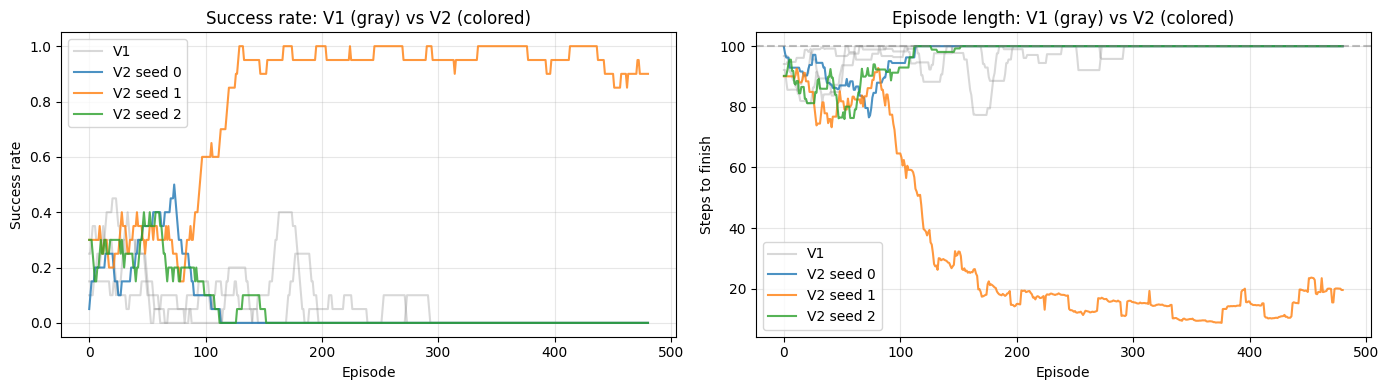

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left success rate, V1 in muted colors, V2 in bold
for i, r in enumerate(v1_runs):
    s = smooth(r['successes'], window=20)
    axes[0].plot(s, alpha=0.3, color='gray', label='V1' if i == 0 else None)
for i, r in enumerate(v2_runs):
    s = smooth(r['successes'], window=20)
    axes[0].plot(s, alpha=0.8, label=f'V2 seed {i}')
axes[0].set_title('Success rate: V1 (gray) vs V2 (colored)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Success rate')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

# right: episode length comparison
for i, r in enumerate(v1_runs):
    s = smooth(r['lengths'], window=20)
    axes[1].plot(s, alpha=0.3, color='gray', label='V1' if i == 0 else None)
for i, r in enumerate(v2_runs):
    s = smooth(r['lengths'], window=20)
    axes[1].plot(s, alpha=0.8, label=f'V2 seed {i}')
axes[1].set_title('Episode length: V1 (gray) vs V2 (colored)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps to finish')
axes[1].axhline(MAX_STEPS, color='gray', linestyle='--', alpha=0.5)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## V2 diagnosis

Replay gave a striking but unstable result. One seed converged almost perfectly. The other two collapsed like V1 partial learning and then complete failure

The buffer breaks correlation between consecutive transitions, which is why the lucky seed could lock in a good policy instead of forgetting it. But targets are still computed by the network being trained, so when early exploration fails to find the pallet, the network drifts on bad targets and never recovers, basically the same failure mode as V1.
